In [22]:
import numpy as np
import torch
import pandas as pd
import time
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from sklearn.exceptions import ConvergenceWarning
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import gc

from wasserstein_ica import WassersteinICA

In [23]:
import os
import random

def set_universal_seed(seed=42):
    # 1. Python built-in random module
    random.seed(seed)
    
    # 2. OS Environment variable (forces Python hash randomization to be deterministic)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. NumPy
    np.random.seed(seed)
    
    # 4. PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU
        # Forces deterministic cuDNN algorithms
        torch.backends.cudnn.deterministic = True 
        torch.backends.cudnn.benchmark = False

# Call the function at the top of your notebook
set_universal_seed(42)

In [24]:
# ==========================================
# 1. Global Thesis Configuration & Helpers
# ==========================================
def set_thesis_theme():
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    plt.rcParams.update({
        'figure.figsize': (24, 10), # Doubled figure size
        'figure.dpi': 300,
        'axes.prop_cycle': plt.cycler(color=thesis_colors),
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 24,           # Doubled base font size
        'axes.titlesize': 28,      # Doubled title size
        'axes.labelsize': 24,      # Doubled label size
        'legend.frameon': True,
        'legend.fontsize': 22,     # Doubled legend font size
        'lines.linewidth': 4.5     # Thicker lines for huge plots
    })

set_thesis_theme()

In [25]:
# =====================================================================
#  0. PAPER FIGURE STYLE  (scoped; does not disturb set_thesis_theme)
# =====================================================================
from contextlib import contextmanager
import matplotlib.pyplot as plt
import numpy as np

PAPER_RC = {
    "figure.dpi": 120, "savefig.dpi": 400, "savefig.bbox": "tight",
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "figure.titlesize": 9.5,
    "axes.linewidth": 0.7, "lines.linewidth": 1.4,
    "xtick.major.width": 0.7, "ytick.major.width": 0.7,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linewidth": 0.5,
    "grid.linestyle": "-", "legend.frameon": False,
}

@contextmanager
def paper_style(**over):
    rc = dict(PAPER_RC); rc.update(over)
    with plt.rc_context(rc):
        yield

def sci(v, digits=2):
    """LaTeX scientific notation, e.g. 1.13\\times 10^{-3}."""
    m, e = f"{v:.{digits}e}".split("e")
    return f"{m}\\times 10^{{{int(e)}}}"

def exp10(v):
    return 0 if v <= 0 else int(np.floor(np.log10(v)))

print("paper style ready")

paper style ready


In [26]:
def amari_error(W, A):
    if W is None or np.any(np.isnan(W)): return np.nan
    P = np.abs(np.dot(W, A))
    n = P.shape[0]
    row_sum = np.sum(P / np.max(P, axis=1, keepdims=True), axis=1) - 1.0
    col_sum = np.sum(P / np.max(P, axis=0, keepdims=True), axis=0) - 1.0
    return (np.sum(row_sum) + np.sum(col_sum)) / (2 * n)

In [27]:
# ==========================================
# 2. Unified Data Generators
# ==========================================
def generate_mixture(n_dim, n_samples, config_type, param=None, seed=None):
    if seed is not None: np.random.seed(seed)
    
    # Standard Generators
    def gen_laplace(): return np.random.laplace(0, 1/np.sqrt(2), size=n_samples)
    def gen_bernoulli(): return np.random.choice([-1.0, 1.0], size=n_samples)
    def gen_uniform(): return np.random.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    def gen_student_t(): s = np.random.standard_t(df=3, size=n_samples); return s / np.std(s)
    
    # Parameterized Discrete Generators
    def gen_poisson(lam=3.0): s = np.random.poisson(lam=lam, size=n_samples); return (s - np.mean(s)) / np.std(s)
    def gen_binomial(n=10, p=0.5): s = np.random.binomial(n=n, p=p, size=n_samples); return (s - np.mean(s)) / np.std(s)
    
    # Positive continuous
    def gen_chisquare(): s = np.random.chisquare(df=2, size=n_samples); return (s - np.mean(s)) / np.std(s)
    def gen_exponential(): s = np.random.exponential(scale=1.0, size=n_samples); return (s - np.mean(s)) / np.std(s)

    pools = {
        'Full Hybrid': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, gen_poisson, gen_binomial, gen_chisquare, gen_exponential],
        'Continuous Only': [gen_laplace, gen_uniform, gen_student_t, gen_chisquare, gen_exponential],
        'Discrete Only': [gen_bernoulli, gen_poisson, gen_binomial],
        'Strictly Super-Gaussian': [gen_laplace, gen_student_t, gen_chisquare, gen_exponential],
        'Zero Gaussian': [gen_laplace, gen_bernoulli, gen_uniform, gen_student_t, gen_poisson, gen_binomial, gen_chisquare, gen_exponential]
    }
    
    sources = []
    
    # Mode A: Ablation Pools
    if config_type in pools:
        active_pool = pools[config_type]
        if config_type != 'Zero Gaussian':
            sources.append(np.random.normal(0, 1, size=n_samples)) # Add Gaussian
            n_to_gen = n_dim - 1
        else:
            n_to_gen = n_dim
        for _ in range(n_to_gen): sources.append(np.random.choice(active_pool)())
            
    # Mode B: Single Isolated Discrete Type
    else:
        sources.append(np.random.normal(0, 1, size=n_samples)) # Baseline Gaussian
        for _ in range(n_dim - 1):
            if config_type == 'Bernoulli': sources.append(gen_bernoulli())
            elif config_type == 'Poisson': sources.append(gen_poisson(lam=param if param else 3.0))
            elif config_type == 'Binomial': sources.append(gen_binomial(n=param if param else 10))
            
    S = np.stack(sources)
    np.random.shuffle(S) # Hide the Gaussian
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
    return A @ S, A

In [28]:
# ==========================================
# 3. Unified Worker Function (UPDATED)
# ==========================================
def run_ica_trial(dim, trial, n_samples, config_type, method, param=None):
    torch.set_num_threads(1)
    X_np, A_true = generate_mixture(dim, n_samples, config_type, param, seed=trial)
    
    score = np.nan
    converged = False

    if method == 'FastICA':
            # --- Fair Convergence Restarts for FastICA ---
            score = np.nan
            converged = False
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                for r in range(50): # Up to 50 Random initializations
                    try:
                        seed_r = trial * 1000 + r
                        # max_iter=10000 ensures we give it plenty of time to converge
                        fast_ica = FastICA(n_components=dim, max_iter=10000, tol=1e-4, random_state=seed_r)
                        fast_ica.fit(X_np.T)
                        
                        # Check if the solver returned a valid matrix (no NaNs or Infs)
                        if not np.any(np.isnan(fast_ica.components_)) and not np.any(np.isinf(fast_ica.components_)):
                            
                            # Only compute the Amari error ONCE on the first valid convergence
                            score = amari_error(fast_ica.components_, A_true)
                            
                            if not np.isnan(score): 
                                converged = True
                                break #  Stop searching once a valid solution is found!
                    except Exception: 
                        pass

    elif method == 'OT-ICA':
        try:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            print("Running on: ", device)
            X_torch = torch.tensor(X_np, dtype=torch.float32).to(device)
            ica = WassersteinICA(X_torch)
            ica.whiten()
            W_white = ica.W_white.cpu().numpy()
            
            extracted = []
            n_restarts = min(dim * 4, 150)
            for _ in range(dim):
                prev = torch.stack(extracted) if extracted else None
                w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts, dither_sigma=0.1)
                extracted.append(w)
                
            W_stiefel = ica.optimize_symmetric(n_components=dim, max_iter=400, lr=0.2, init_w=torch.stack(extracted), optimizer='stiefel', dither_sigma=0.1, batch_size=1024)
            score = amari_error(W_stiefel.cpu().numpy() @ W_white, A_true)
            if not np.isnan(score) and score < 1.0: converged = True
        except Exception: pass
    
    # --- Aggressive Memory Cleanup ---
    try:
        del X_np
        del A_true
        if 'X_torch' in locals():
            del X_torch
        if 'ica' in locals():
            del ica
        if 'fast_ica' in locals():
            del fast_ica
    except NameError:
        pass
        
    gc.collect() # Force the OS to reclaim the RAM immediately

    return {'Dim': dim, 'Config': config_type, 'Config_Param': param, 'Method': method, 'Error': score, 'Conv': int(converged)}

In [29]:
def plot_results(df, title, palette, x_col='Config', ylim=2.0, conv_plot=True):
    # 1. Prepare Amari Error Data
    df_plot = df.copy()
    df_plot['Error'] = df_plot['Error'].fillna(1.5) 

    # 2. Prepare Convergence Data
    df_conv_raw = df[df['Method'] == 'FastICA'].copy()
    df_conv_raw['Success Rate (%)'] = df_conv_raw['Conv'] * 100

    # --- Massive Font Size Controls ---
    TITLE_FS = 30   
    LABEL_FS = 30   
    TICK_FS = 28    
    LEGEND_FS = 28  
    ANNOT_FS = 22   # Font size for the percentage text on bars
    # --------------------------------------
    if conv_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
        
        # --- Subplot 1: Amari Error (Barplot with alpha) ---
        # Default total width is 0.8, split across 2 hues = ~0.4 width per bar
        sns.barplot(data=df_plot, x=x_col, y='Error', hue='Method', ax=ax1, 
                    palette=palette, edgecolor='black', errorbar='ci', alpha=0.7)
        
        ax1.set_title(f"Amari Error: {title}", fontsize=TITLE_FS, pad=20, fontweight='bold')
        ax1.set_xlabel(x_col, fontsize=LABEL_FS, labelpad=15)
        ax1.set_ylabel('Error', fontsize=LABEL_FS, labelpad=15)
        ax1.tick_params(axis='both', labelsize=TICK_FS)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha="right")
        ax1.legend(title='Method', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
        ax1.set_ylim(0, ylim) 

        # --- FIXED: Bolder Good Separation Threshold Line ---
        #ax1.axhline(0.3, color='black', linestyle=':', linewidth=3, alpha=0.6)
        # Added a white bbox so the text pops out over the bars
        #ax1.text(ax1.get_xlim()[0] + 0.1, 0.32, 'Good Separation', color='black', 
        #         fontsize=ANNOT_FS, fontweight='bold', 
        #         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

        # --- Subplot 2: Convergence Rate (Barplot with matching width, no error band) ---
        fast_palette = {'FastICA': palette['FastICA']}
        sns.barplot(data=df_conv_raw, x=x_col, y='Success Rate (%)', hue='Method', ax=ax2, 
                    palette=fast_palette, edgecolor='black', errorbar=None, alpha=0.7, width=0.4)
        
        ax2.set_title(f"FastICA Convergence: {title}", fontsize=TITLE_FS, pad=20, fontweight='bold')
        ax2.set_xlabel(x_col, fontsize=LABEL_FS, labelpad=15)
        ax2.set_ylabel('Success Rate (%)', fontsize=LABEL_FS, labelpad=15)
        ax2.tick_params(axis='both', labelsize=TICK_FS)
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha="right")
        
        # --- FIXED: Only annotate the actual FastICA bars ---
        # Seaborn generates patches for all hue levels. Since FastICA is the first hue, 
        # its patches are the first N elements in ax2.patches (where N is the number of x categories)
        n_categories = df_conv_raw[x_col].nunique()
        for p in ax2.patches[:n_categories]:
            height = p.get_height()
            if not np.isnan(height):
                ax2.annotate(f'{height:.0f}%', 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', 
                            fontsize=ANNOT_FS, fontweight='bold', color='black', 
                            xytext=(0, 5), textcoords='offset points')
        
        # Explicitly remove the legend from the right plot
        if ax2.get_legend() is not None:
            ax2.get_legend().remove()
            
        ax2.set_ylim(0, 115) # Slightly increased to leave room for the 100% text

        plt.tight_layout()
        
        # Generate automatic safe file name for PDF
        file_name = f"{title.replace(' ', '_').replace(':', '').replace('(', '').replace(')', '').replace('-', '_').lower()}.pdf"
        plt.savefig(file_name, format='pdf', bbox_inches='tight')
        plt.show()
        
        display(df.groupby(['Method', x_col, 'Dim'])[['Error', 'Conv']].mean().round(4))
    
    else:
        fig, (ax1) = plt.subplots(1, 1, figsize=(12, 10))
        
        # --- Subplot 1: Amari Error (Barplot with alpha) ---
        # Default total width is 0.8, split across 2 hues = ~0.4 width per bar
        sns.barplot(data=df_plot, x=x_col, y='Error', hue='Method', ax=ax1, 
                    palette=palette, edgecolor='black', errorbar='ci', alpha=0.7)
        
        ax1.set_title(f"Amari Error: {title}", fontsize=TITLE_FS, pad=20, fontweight='bold')
        ax1.set_xlabel(x_col, fontsize=LABEL_FS, labelpad=15)
        ax1.set_ylabel('Error', fontsize=LABEL_FS, labelpad=15)
        ax1.tick_params(axis='both', labelsize=TICK_FS)
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha="right")
        ax1.legend(title='Method', fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
        ax1.set_ylim(0, ylim) 

        # --- FIXED: Bolder Good Separation Threshold Line ---
        #ax1.axhline(0.3, color='black', linestyle=':', linewidth=3, alpha=0.6)
        # Added a white bbox so the text pops out over the bars
        #ax1.text(ax1.get_xlim()[0] + 0.1, 0.32, 'Good Separation', color='black', 
        #         fontsize=ANNOT_FS, fontweight='bold', 
        #         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

        # --- Subplot 2: Convergence Rate (Barplot with matching width, no error band) ---
        #fast_palette = {'FastICA': palette['FastICA']}
        #sns.barplot(data=df_conv_raw, x=x_col, y='Success Rate (%)', hue='Method', ax=ax2, 
        #            palette=fast_palette, edgecolor='black', errorbar=None, alpha=0.7, width=0.4)
        
        #ax2.set_title(f"FastICA Convergence: {title}", fontsize=TITLE_FS, pad=20, fontweight='bold')
        #ax2.set_xlabel(x_col, fontsize=LABEL_FS, labelpad=15)
        #ax2.set_ylabel('Success Rate (%)', fontsize=LABEL_FS, labelpad=15)
        #ax2.tick_params(axis='both', labelsize=TICK_FS)
        #ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha="right")
        
        # --- FIXED: Only annotate the actual FastICA bars ---
        # Seaborn generates patches for all hue levels. Since FastICA is the first hue, 
        # its patches are the first N elements in ax2.patches (where N is the number of x categories)
        #n_categories = df_conv_raw[x_col].nunique()
        #for p in ax2.patches[:n_categories]:
        #    height = p.get_height()
        #    if not np.isnan(height):
        #        ax2.annotate(f'{height:.0f}%', 
        #                    (p.get_x() + p.get_width() / 2., height), 
        #                    ha='center', va='bottom', 
        #                    fontsize=ANNOT_FS, fontweight='bold', color='black', 
        #                    xytext=(0, 5), textcoords='offset points')
        
        # Explicitly remove the legend from the right plot
        #if ax2.get_legend() is not None:
        #    ax2.get_legend().remove()
            
        #ax2.set_ylim(0, 115) # Slightly increased to leave room for the 100% text

        plt.tight_layout()
        
        # Generate automatic safe file name for PDF
        file_name = f"{title.replace(' ', '_').replace(':', '').replace('(', '').replace(')', '').replace('-', '_').lower()}.pdf"
        plt.savefig(file_name, format='pdf', bbox_inches='tight')
        plt.show()
        
        display(df.groupby(['Method', x_col, 'Dim'])[['Error', 'Conv']].mean().round(4))

In [30]:
# =====================================================================
#  A. SHARED UTILITIES FOR THE DISCRETE DIAGNOSTIC
# =====================================================================
import numpy as np, torch, scipy.stats, pandas as pd
import matplotlib.pyplot as plt

DEV = "cuda" if torch.cuda.is_available() else "cpu"
PALETTE = {"FastICA": "#0173B2", "OT-ICA": "#D55E00"}


def analytical_target(n):
    """Exact per-bin Gaussian mean, matching WassersteinICA._compute_analytical_target."""
    p = np.linspace(0.0, 1.0, n + 1)
    z = scipy.stats.norm.ppf(p)
    phi = scipy.stats.norm.pdf(z)
    phi[0] = phi[-1] = 0.0
    return n * (phi[:-1] - phi[1:])


# E[log cosh N(0,1)] by quadrature (stable; avoids a noisy empirical baseline)
_zq, _wq = np.polynomial.hermite_e.hermegauss(200)
C_GAUSS = float(np.sum(_wq * np.log(np.cosh(_zq))) / np.sqrt(2 * np.pi))
print(f"E[log cosh N(0,1)] = {C_GAUSS:.6f}")


def std_(y):
    return (y - y.mean()) / y.std()


def w2_sq(y, target):
    """W_2^2 between the standardised projection and the Gaussian."""
    return float(np.mean((np.sort(std_(y)) - target) ** 2))


def logcosh_sq(y):
    """FastICA's proxy negentropy (E[G(y)] - E[G(nu)])^2."""
    return float((np.mean(np.log(np.cosh(std_(y)))) - C_GAUSS) ** 2)


def whiten_np(X):
    """X: (d, n). Returns whitened data and the whitening matrix."""
    Xc = X - X.mean(1, keepdims=True)
    d, V = np.linalg.eigh(np.cov(Xc))
    Wh = V @ np.diag(1.0 / np.sqrt(np.maximum(d, 1e-12))) @ V.T
    return Wh @ Xc, Wh


def true_dirs(S, Xw):
    """Unit rows w_i with w_i @ Xw proportional to source i."""
    Sc = (S - S.mean(1, keepdims=True)) / S.std(1, keepdims=True)
    W = Sc @ np.linalg.pinv(Xw)
    return W / np.linalg.norm(W, axis=1, keepdims=True)


def make_sources(kind, param, n, n_dim, include_gaussian, rng):
    """Returns (S, is_gaussian_mask). One Gaussian if include_gaussian, rest discrete."""
    rows, gm = [], []
    n_disc = n_dim - int(include_gaussian)
    if include_gaussian:
        rows.append(rng.standard_normal(n)); gm.append(True)
    for _ in range(n_disc):
        s = (rng.poisson(param, n) if kind == "Poisson"
             else rng.binomial(int(param), 0.5, n)).astype(float)
        rows.append((s - s.mean()) / s.std()); gm.append(False)
    return np.vstack(rows), np.array(gm)


def make_mixture(kind, param, n, n_dim, include_gaussian=True, seed=0, max_cond=100.0):
    """Well-conditioned linear mixture; returns whitened X, sources, true directions."""
    rng = np.random.default_rng(seed)
    S, gm = make_sources(kind, param, n, n_dim, include_gaussian, rng)
    while True:
        A = rng.standard_normal((n_dim, n_dim))
        if np.linalg.cond(A) < max_cond:
            break
    Xw, _ = whiten_np(A @ S)
    return Xw, S, true_dirs(S, Xw), gm


CONFIGS = [("I",   "Poisson",  0.5, r"More non-Gaussian Poisson ($\lambda=0.5$)"),
           ("II",  "Poisson",  3.0, r"Less non-Gaussian Poisson ($\lambda=3.0$)"),
           ("III", "Binomial", 2,   r"More non-Gaussian Binomial ($n=2$)"),
           ("IV",  "Binomial", 10,  r"Less non-Gaussian Binomial ($n=10$)")]

E[log cosh N(0,1)] = 0.374567


In [31]:
# =====================================================================
#  B. CONTRAST SENSITIVITY vs A GAUSSIAN NULL
# =====================================================================
N_SAMP, N_NULL, N_BOOT = 10_000, 400, 400
TGT = analytical_target(N_SAMP)
rng = np.random.default_rng(0)

null_w2 = np.array([w2_sq(rng.standard_normal(N_SAMP), TGT) for _ in range(N_NULL)])
null_lc = np.array([logcosh_sq(rng.standard_normal(N_SAMP)) for _ in range(N_NULL)])
print(f"Gaussian null   W2^2   : {null_w2.mean():.2e} +/- {null_w2.std():.2e}")
print(f"Gaussian null   (dG)^2 : {null_lc.mean():.2e} +/- {null_lc.std():.2e}\n")

MARGINALS = [("Laplace (baseline)",          lambda r: r.laplace(0, 1, N_SAMP)),
             ("Poisson ($\\lambda=0.5$)",    lambda r: r.poisson(0.5, N_SAMP)),
             ("Poisson ($\\lambda=3.0$)",    lambda r: r.poisson(3.0, N_SAMP)),
             ("Binomial ($n=2$)",            lambda r: r.binomial(2, 0.5, N_SAMP)),
             ("Binomial ($n=10$)",           lambda r: r.binomial(10, 0.5, N_SAMP))]

rows = []
for name, gen in MARGINALS:
    s = gen(np.random.default_rng(1)).astype(float)
    v_w2, v_lc = w2_sq(s, TGT), logcosh_sq(s)
    rows.append(dict(dist=name, w2=v_w2, lc=v_lc,
                     w2_z=(v_w2 - null_w2.mean()) / null_w2.std(),
                     lc_z=(v_lc - null_lc.mean()) / null_lc.std()))

z0_w2, z0_lc = rows[0]["w2_z"], rows[0]["lc_z"]        # Laplace reference
for r in rows:
    r["w2_r"], r["lc_r"] = r["w2_z"] / z0_w2, r["lc_z"] / z0_lc

print(f"{'Distribution':<26}{'W2^2':>9}{'z':>8}{'rel':>7}"
      f"{'(dG)^2':>11}{'z':>8}{'rel':>7}")
print("-" * 76)
for r in rows:
    print(f"{r['dist']:<26}{r['w2']:>9.4f}{r['w2_z']:>8.0f}{r['w2_r']:>7.2f}"
          f"{r['lc']:>11.2e}{r['lc_z']:>8.1f}{r['lc_r']:>7.3f}")
print("\nrel = detectability relative to the Laplace baseline "
      "(z / z_Laplace, same contrast).")

# ---------------------------- LaTeX ----------------------------
print("\n" + r"\begin{tabular}{lcccccc}")
print(r"\toprule")
print(r"& \multicolumn{3}{c}{$W_2^2$} & \multicolumn{3}{c}{Logcosh} \\")
print(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
print(r"Distribution & value & $z$ & rel. & value & $z$ & rel. \\")
print(r"\midrule")
for r in rows:
    print(f"{r['dist']} & {r['w2']:.4f} & {r['w2_z']:.0f} & {r['w2_r']:.2f} "
          f"& ${sci(r['lc'])}$ & {r['lc_z']:.1f} & {r['lc_r']:.3f} \\\\")
print(r"\bottomrule" + "\n" + r"\end{tabular}")

Gaussian null   W2^2   : 1.96e-04 +/- 7.95e-05
Gaussian null   (dG)^2 : 6.13e-07 +/- 8.55e-07

Distribution                   W2^2       z    rel     (dG)^2       z    rel
----------------------------------------------------------------------------
Laplace (baseline)           0.0329     412   1.00   1.13e-03  1322.6  1.000
Poisson ($\lambda=0.5$)      0.3394    4269  10.37   2.22e-04   258.6  0.196
Poisson ($\lambda=3.0$)      0.0517     649   1.57   3.88e-06     3.8  0.003
Binomial ($n=2$)             0.2022    2542   6.17   2.25e-04   262.2  0.198
Binomial ($n=10$)            0.0342     427   1.04   1.09e-05    12.0  0.009

rel = detectability relative to the Laplace baseline (z / z_Laplace, same contrast).

\begin{tabular}{lcccccc}
\toprule
& \multicolumn{3}{c}{$W_2^2$} & \multicolumn{3}{c}{Logcosh} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Distribution & value & $z$ & rel. & value & $z$ & rel. \\
\midrule
Laplace (baseline) & 0.0329 & 412 & 1.00 & $1.13\times 10^{-3}$ & 1322.6 & 1.0

In [32]:
# =====================================================================
#  B. CONTRAST SENSITIVITY vs A GAUSSIAN NULL
# =====================================================================
import numpy as np

# (Assuming w2_sq, logcosh_sq, analytical_target, and sci are defined above)

N_SAMP, N_NULL, N_BOOT = 10_000, 400, 400
TGT = analytical_target(N_SAMP)
rng = np.random.default_rng(0)

null_w2 = np.array([w2_sq(rng.standard_normal(N_SAMP), TGT) for _ in range(N_NULL)])
null_lc = np.array([logcosh_sq(rng.standard_normal(N_SAMP)) for _ in range(N_NULL)])
print(f"Gaussian null   W2^2   : {null_w2.mean():.2e} +/- {null_w2.std():.2e}")
print(f"Gaussian null   (dG)^2 : {null_lc.mean():.2e} +/- {null_lc.std():.2e}\n")

MARGINALS = [("Laplace (baseline)",          lambda r: r.laplace(0, 1, N_SAMP)),
             ("Poisson ($\\lambda=0.5$)",    lambda r: r.poisson(0.5, N_SAMP)),
             ("Poisson ($\\lambda=3.0$)",    lambda r: r.poisson(3.0, N_SAMP)),
             ("Binomial ($n=2$)",            lambda r: r.binomial(2, 0.5, N_SAMP)),
             ("Binomial ($n=10$)",           lambda r: r.binomial(10, 0.5, N_SAMP))]

rows = []
for name, gen in MARGINALS:
    s = gen(np.random.default_rng(1)).astype(float)
    # Ensure inputs are standardized (mean=0, var=1) before passing to contrast!
    s = (s - s.mean()) / s.std() 
    
    v_w2, v_lc = w2_sq(s, TGT), logcosh_sq(s)
    rows.append(dict(dist=name, w2=v_w2, lc=v_lc,
                     w2_z=(v_w2 - null_w2.mean()) / null_w2.std(),
                     lc_z=(v_lc - null_lc.mean()) / null_lc.std()))

# --- THE UPDATE IS HERE ---
# 1. Grab the Laplace Z-scores (for the old method)
z0_w2, z0_lc = rows[0]["w2_z"], rows[0]["lc_z"]        

# 2. Grab the Laplace raw values (for the new explicit method)
v0_w2, v0_lc = rows[0]["w2"], rows[0]["lc"]            

for r in rows:
    # Old Method: Ratio of Z-scores
    r["w2_r_z"] = r["w2_z"] / z0_w2
    r["lc_r_z"] = r["lc_z"] / z0_lc
    
    # New Method: Explicit mean-subtracted ratio (standard deviations cancel out)
    r["w2_r_exp"] = (r["w2"] - null_w2.mean()) / (v0_w2 - null_w2.mean())
    r["lc_r_exp"] = (r["lc"] - null_lc.mean()) / (v0_lc - null_lc.mean())

# --- UPDATED PRINT BLOCK TO SHOW BOTH ---
print(f"{'Distribution':<26}{'W2^2':>9}{'z':>8}{'rel(z)':>8}{'rel(exp)':>10}"
      f"{'(dG)^2':>11}{'z':>8}{'rel(z)':>8}{'rel(exp)':>10}")
print("-" * 98)
for r in rows:
    print(f"{r['dist']:<26}{r['w2']:>9.4f}{r['w2_z']:>8.0f}{r['w2_r_z']:>8.2f}{r['w2_r_exp']:>10.2f}"
          f"{r['lc']:>11.2e}{r['lc_z']:>8.1f}{r['lc_r_z']:>8.3f}{r['lc_r_exp']:>10.3f}")

# ---------------------------- LaTeX ----------------------------
# The LaTeX output simply uses the explicit relative score ('w2_r_exp')
print("\n" + r"\begin{tabular}{lcccccc}")
print(r"\toprule")
print(r"& \multicolumn{3}{c}{$W_2^2$} & \multicolumn{3}{c}{Logcosh} \\")
print(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
print(r"Distribution & value & $z$ & rel. & value & $z$ & rel. \\")
print(r"\midrule")
for r in rows:
    print(f"{r['dist']} & {r['w2']:.4f} & {r['w2_z']:.0f} & {r['w2_r_exp']:.2f} "
          f"& ${sci(r['lc'])}$ & {r['lc_z']:.1f} & {r['lc_r_exp']:.3f} \\\\")
print(r"\bottomrule" + "\n" + r"\end{tabular}")

Gaussian null   W2^2   : 1.96e-04 +/- 7.95e-05
Gaussian null   (dG)^2 : 6.13e-07 +/- 8.55e-07

Distribution                   W2^2       z  rel(z)  rel(exp)     (dG)^2       z  rel(z)  rel(exp)
--------------------------------------------------------------------------------------------------
Laplace (baseline)           0.0329     412    1.00      1.00   1.13e-03  1322.6   1.000     1.000
Poisson ($\lambda=0.5$)      0.3394    4269   10.37     10.37   2.22e-04   258.6   0.196     0.196
Poisson ($\lambda=3.0$)      0.0517     649    1.57      1.57   3.88e-06     3.8   0.003     0.003
Binomial ($n=2$)             0.2022    2542    6.17      6.17   2.25e-04   262.2   0.198     0.198
Binomial ($n=10$)            0.0342     427    1.04      1.04   1.09e-05    12.0   0.009     0.009

\begin{tabular}{lcccccc}
\toprule
& \multicolumn{3}{c}{$W_2^2$} & \multicolumn{3}{c}{Logcosh} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Distribution & value & $z$ & rel. & value & $z$ & rel. \\
\midrule
Laplace (b

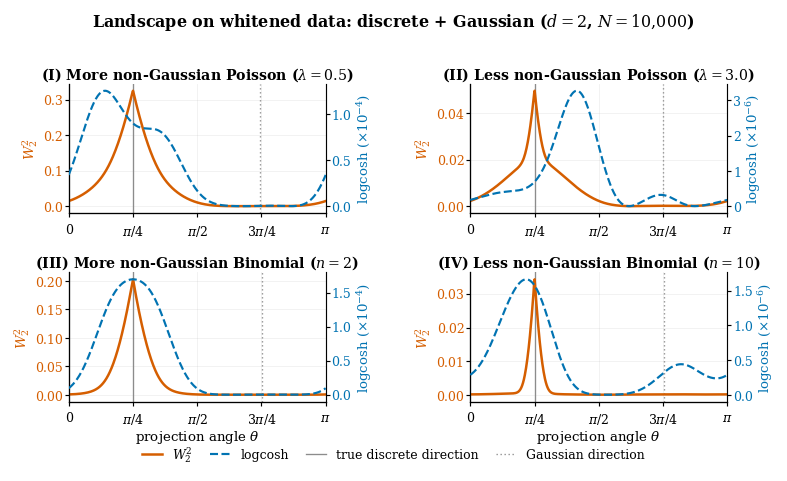


Peak-recovery error (degrees from nearest true direction) -- discrete + Gaussian:
  (I)  W2  0.08    logcosh  19.5
  (II)  W2  0.08    logcosh  29.5
  (III)  W2  0.08    logcosh   0.1
  (IV)  W2  0.08    logcosh   5.9


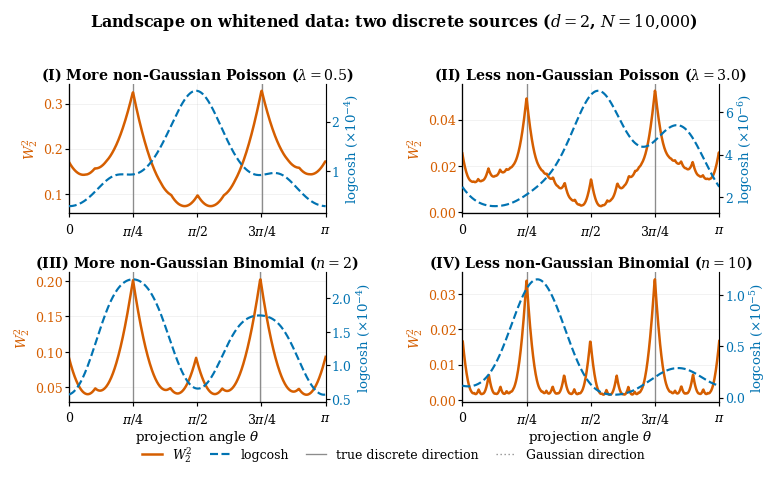


Peak-recovery error (degrees from nearest true direction) -- two discrete sources:
  (I)  W2  0.12    logcosh  44.2
  (II)  W2  0.09    logcosh  39.8
  (III)  W2  0.10    logcosh   0.1
  (IV)  W2  0.09    logcosh   7.6


In [11]:
# =====================================================================
#  C. OPTIMISATION LANDSCAPE  (whitened data, true directions marked)
#     Both contrasts are pi-periodic, so [0, pi] is the complete landscape.
#     The whitened basis is defined only up to rotation, so we rotate it
#     to place the first discrete direction at ALIGN (cosmetic only).
# =====================================================================
ALIGN = np.pi / 4          # set to None to keep the raw random orientation


def landscape_panel(ax, roman, kind, param, title, n=10_000, seed=0,
                    include_gaussian=True, n_theta=600, align=ALIGN):
    Xw, S, Wt, gm = make_mixture(kind, param, n, 2, include_gaussian, seed)

    if align is not None:                       # canonicalise the basis
        k0 = np.where(~gm)[0][0]
        phi = align - np.arctan2(Wt[k0, 1], Wt[k0, 0])
        R = np.array([[np.cos(phi), -np.sin(phi)],
                      [np.sin(phi),  np.cos(phi)]])
        Xw, Wt = R @ Xw, Wt @ R.T               # still whitened; w @ Xw invariant

    tgt = analytical_target(n)
    th = np.linspace(0, np.pi, n_theta)

    w2c, lcc = [], []
    for t in th:
        y = np.array([np.cos(t), np.sin(t)]) @ Xw
        w2c.append(w2_sq(y, tgt)); lcc.append(logcosh_sq(y))
    w2c, lcc = np.array(w2c), np.array(lcc)

    for k in range(Wt.shape[0]):                # true directions, behind curves
        a = np.arctan2(Wt[k, 1], Wt[k, 0]) % np.pi
        ax.axvline(a, color="0.55", lw=0.8, zorder=1,
                   ls=(0, (1, 2)) if gm[k] else "-")

    ax.plot(th, w2c, color=PALETTE["OT-ICA"], lw=1.5, zorder=4)
    ax.set_ylabel("$W_2^2$", color=PALETTE["OT-ICA"], labelpad=2)
    ax.tick_params(axis="y", labelcolor=PALETTE["OT-ICA"], pad=1)
    ax.set_xticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
    ax.set_xlim(0, np.pi)
    ax.set_title(f"({roman}) {title}", fontweight="bold", pad=3)
    ax.margins(y=0.06)

    e = exp10(lcc.max())                        # rescale to kill the offset label
    ax2 = ax.twinx()
    ax2.plot(th, lcc / 10.0 ** e, color=PALETTE["FastICA"], lw=1.3, ls="--", zorder=3)
    ax2.set_ylabel(f"logcosh ($\\times 10^{{{e}}}$)",
                   color=PALETTE["FastICA"], labelpad=2)
    ax2.tick_params(axis="y", labelcolor=PALETTE["FastICA"], pad=1)
    ax2.spines["right"].set_visible(True)
    ax2.spines["right"].set_linewidth(0.7)
    ax2.grid(False); ax2.margins(y=0.06)

    tru = np.array(sorted({np.arctan2(Wt[k, 1], Wt[k, 0]) % np.pi
                           for k in np.where(~gm)[0]}))
    err = {}
    for tag, c in (("W2", w2c), ("logcosh", lcc)):
        pk = th[np.argmax(c)] % np.pi
        err[tag] = np.degrees(np.min(np.abs(np.angle(np.exp(2j * (pk - tru)))) / 2))
    return err


peak_err = {}
for INC in (True, False):
    with paper_style():
        fig, axs = plt.subplots(2, 2, figsize=(6.6, 3.7))
        errs = {}
        for ax, (roman, kind, param, title) in zip(axs.flat, CONFIGS):
            errs[roman] = landscape_panel(ax, roman, kind, param, title,
                                          include_gaussian=INC)
        for ax in axs[1]:
            ax.set_xlabel(r"projection angle $\theta$", labelpad=1)

        src = "discrete + Gaussian" if INC else "two discrete sources"
        fig.suptitle(f"Landscape on whitened data: {src} "
                     f"($d=2$, $N=10{{,}}000$)", fontweight="bold", y=1.01)
        fig.legend(handles=[
            plt.Line2D([], [], color=PALETTE["OT-ICA"], lw=1.5, label="$W_2^2$"),
            plt.Line2D([], [], color=PALETTE["FastICA"], lw=1.3, ls="--", label="logcosh"),
            plt.Line2D([], [], color="0.55", lw=0.8, label="true discrete direction"),
            plt.Line2D([], [], color="0.55", lw=0.8, ls=(0, (1, 2)), label="Gaussian direction")],
            loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.035),
            handlelength=1.6, columnspacing=1.4)
        fig.tight_layout(h_pad=1.2, w_pad=2.4)
        fig.savefig(f"landscape_{'gauss' if INC else 'twodisc'}.pdf")
        plt.show()

    peak_err[src] = errs
    print(f"\nPeak-recovery error (degrees from nearest true direction) -- {src}:")
    for r, e in errs.items():
        print(f"  ({r})  W2 {e['W2']:5.2f}    logcosh {e['logcosh']:5.1f}")

In [18]:
# =====================================================================
#  D. WHY IT FAILS AT HIGH d: contrast strength vs basin volume
# =====================================================================
def _w2_batch(W, Xw_t, tgt_t):
    return torch.mean((torch.sort(W @ Xw_t, dim=1)[0] - tgt_t) ** 2, dim=1)


def _lc_batch(W, Xw_t, _):
    return (torch.mean(torch.log(torch.cosh(W @ Xw_t)), dim=1) - C_GAUSS) ** 2


def diagnose(kind, param, d, n=10_000, seed=0, include_gaussian=True,
             n_rand=1500, n_starts=300, steps=400, lr=0.05, contrast="w2"):
    Xw, S, Wt, gm = make_mixture(kind, param, n, d, include_gaussian, seed)
    Xt = torch.tensor(Xw, dtype=torch.float32, device=DEV)
    tgt = torch.tensor(analytical_target(n), dtype=torch.float32, device=DEV)
    fn = _w2_batch if contrast == "w2" else _lc_batch
    T = torch.tensor(Wt[~gm], dtype=torch.float32, device=DEV)     # discrete dirs only
    g = torch.Generator(device=DEV).manual_seed(seed)

    # --- contrast at true directions vs random directions ---
    R = torch.randn(n_rand, d, generator=g, device=DEV)
    R = R / R.norm(dim=1, keepdim=True)
    with torch.no_grad():
        c_rand, c_true = fn(R, Xt, tgt), fn(T, Xt, tgt)
    gap_z = ((c_true.mean() - c_rand.mean()) / c_rand.std()).item()

    # --- relative tangent-gradient norm on random directions ---
    Rg = R.clone().requires_grad_(True)
    fn(Rg, Xt, tgt).sum().backward()
    G = Rg.grad
    G = G - (G * Rg.data).sum(1, keepdim=True) * Rg.data
    rel = (G.norm(dim=1) / c_true.mean().clamp_min(1e-12)).detach()
    plateau = (rel < 0.01).float().mean().item()

    # --- basin fraction: projected gradient ascent from random starts ---
    W = torch.randn(n_starts, d, generator=g, device=DEV)
    W = (W / W.norm(dim=1, keepdim=True)).requires_grad_(True)
    step = lr
    for _ in range(steps):
        if W.grad is not None:
            W.grad.zero_()
        fn(W, Xt, tgt).sum().backward()
        with torch.no_grad():
            gr = W.grad - (W.grad * W.data).sum(1, keepdim=True) * W.data
            nr = gr.norm(dim=1, keepdim=True).clamp_min(1e-12)
            W.data += step * torch.where(nr > 1.0, gr / nr, gr)
            W.data /= W.data.norm(dim=1, keepdim=True)
        step *= 0.999
    with torch.no_grad():
        hit = (torch.abs(W.data @ T.T).max(1).values > 0.99).float().mean().item()

    return dict(kind=kind, param=param, d=d, contrast=contrast,
                gap_z=gap_z, plateau=plateau, basin=hit,
                c_true=c_true.mean().item(), c_rand=c_rand.mean().item())


# =====================================================================
#  D. CONTRAST STRENGTH vs BASIN VOLUME ACROSS DIMENSION
# =====================================================================
DIMS = [2, 4, 6, 8, 10]
diag = []
for roman, kind, param, _ in CONFIGS:
    for d in DIMS:
        for c in ("w2", "logcosh"):
            r = diagnose(kind, param, d, contrast=c)
            r["config"] = roman
            diag.append(r)
    print(f"config ({roman}) done")

dg = pd.DataFrame(diag)
print("\n=== gap_z (contrast signal) and basin fraction ===")
print(dg.pivot_table(index=["config", "contrast"], columns="d",
                     values=["gap_z", "basin"]).round(3).to_string())

config (I) done
config (II) done
config (III) done
config (IV) done

=== gap_z (contrast signal) and basin fraction ===
                 basin                              gap_z                                   
d                   2      4      6      8      10     2       4        6        8        10
config contrast                                                                             
I      logcosh   0.100  0.010  0.000  0.000  0.000  1.057   0.544    1.262    1.960    2.809
       w2        0.673  0.760  0.707  0.720  0.750  3.523   7.571   14.557   21.497   33.307
II     logcosh   0.087  0.003  0.000  0.000  0.000 -0.072   1.018    1.673    1.416    1.693
       w2        0.437  0.300  0.193  0.063  0.020  4.186  10.355   15.609   20.895   28.836
III    logcosh   0.057  0.000  0.000  0.000  0.000  1.855   2.995    5.099    7.694   12.200
       w2        0.423  0.340  0.243  0.153  0.077  3.821  12.597   33.399   81.204  180.144
IV     logcosh   0.057  0.000  0.000  0.000

/tmp/ipykernel_638206/1414487112.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


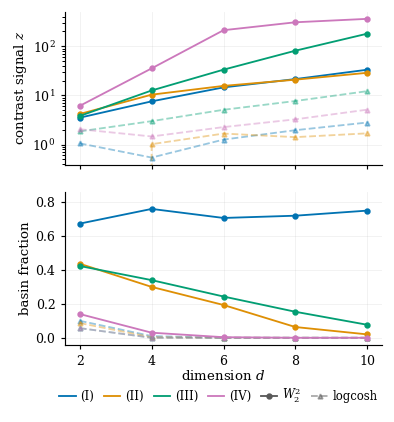

In [19]:
# =====================================================================
#  D2. SCALING DIAGNOSTIC, COLUMN-WIDTH (2 rows x 1 col)
# =====================================================================
CCOL = {"I": "#0173B2", "II": "#DE8F05", "III": "#029E73", "IV": "#CC78BC"}

with paper_style():
    fig, axes = plt.subplots(2, 1, figsize=(3.4, 3.6), sharex=True,
                             gridspec_kw=dict(hspace=0.18))
    for ax, key, lab in [(axes[0], "gap_z",  "contrast signal $z$"),
                         (axes[1], "basin",  "basin fraction")]:
        for roman, *_ in CONFIGS:
            for c, ls, mk, al in (("w2", "-", "o", 1.0), ("logcosh", "--", "^", 0.40)):
                sub = dg[(dg.config == roman) & (dg.contrast == c)].sort_values("d")
                ax.plot(sub.d, sub[key], ls=ls, marker=mk, ms=2.8, lw=1.1,
                        color=CCOL[roman], alpha=al)
        ax.set_ylabel(lab, labelpad=2)
        ax.set_xticks(DIMS)
    axes[0].set_yscale("log")
    axes[1].set_ylim(-0.04, 0.86)
    axes[1].set_xlabel("dimension $d$", labelpad=1)

    h = [plt.Line2D([], [], color=CCOL[r], lw=1.1, label=f"({r})") for r, *_ in CONFIGS]
    h += [plt.Line2D([], [], color="0.35", lw=1.1, marker="o", ms=2.8, label="$W_2^2$"),
          plt.Line2D([], [], color="0.35", lw=1.1, ls="--", marker="^", ms=2.8,
                     alpha=0.5, label="logcosh")]
    fig.legend(handles=h, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.055),
               handlelength=1.4, columnspacing=0.85, handletextpad=0.4, fontsize=7)
    fig.tight_layout()
    fig.savefig("discrete_scaling_diagnostic.pdf")
    plt.show()

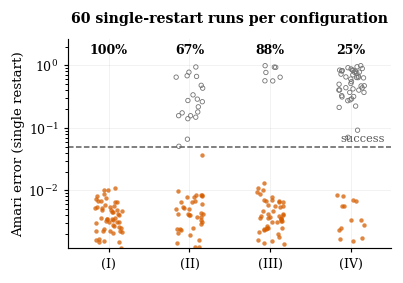

(I) success 100%   median 0.0034   IQR [0.0022, 0.0053]
(II) success  67%   median 0.0066   IQR [0.0033, 0.1567]
(III) success  88%   median 0.0038   IQR [0.0024, 0.0069]
(IV) success  25%   median 0.4130   IQR [0.0552, 0.7118]


In [21]:
# =====================================================================
#  E. SINGLE-RESTART OUTCOMES  (basin width, empirically)
#     n_restarts=1 in the deflation phase, so each run is one draw from
#     the basin-fraction Bernoulli measured in Cell D.
# =====================================================================
from wasserstein_ica import WassersteinICA


def amari(W, A):
    P = np.abs(W @ A)
    n = P.shape[0]
    return (np.sum(np.sum(P / P.max(1, keepdims=True), 1) - 1) +
            np.sum(np.sum(P / P.max(0, keepdims=True), 0) - 1)) / (2 * n)


def single_restart_amari(kind, param, n_runs=60, d=2, n=10_000, dither=0.1):
    out = []
    for t in range(n_runs):
        rng = np.random.default_rng(1000 + t)
        S, _ = make_sources(kind, param, n, d, True, rng)
        while True:
            A = rng.standard_normal((d, d))
            if np.linalg.cond(A) < 100:
                break
        torch.manual_seed(1000 + t)
        m = WassersteinICA(torch.tensor(A @ S, dtype=torch.float32, device=DEV))
        m.whiten()
        ws = []
        for _ in range(d):                                # n_restarts = 1
            prev = torch.stack(ws) if ws else None
            w, _s = m.optimize_wasserstein2(prev_components=prev, max_iter=200,
                                            n_restarts=1, dither_sigma=dither)
            ws.append(w)
        W = m.optimize_symmetric(n_components=d, max_iter=400, lr=0.2,
                                 init_w=torch.stack(ws), optimizer="stiefel",
                                 dither_sigma=dither, batch_size=1024)
        out.append(amari(W.cpu().numpy() @ m.W_white.cpu().numpy(), A))
    return np.array(out)


res = {r: single_restart_amari(k, p) for r, k, p, _ in CONFIGS}

with paper_style():
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    jr = np.random.default_rng(0)
    for i, (roman, *_) in enumerate(CONFIGS):
        a = res[roman]
        ok = a < 0.05
        x = i + jr.uniform(-0.17, 0.17, len(a))
        ax.scatter(x[ok], a[ok], s=7, color=PALETTE["OT-ICA"], alpha=0.75, lw=0)
        ax.scatter(x[~ok], a[~ok], s=7, facecolor="none", edgecolor="0.45", lw=0.5)
        ax.text(i, 1.55, f"{ok.mean():.0%}", ha="center", fontsize=7.5,
                fontweight="bold")
    ax.axhline(0.05, color="0.35", ls="--", lw=0.9)
    ax.text(3.42, 0.055, "success", fontsize=6.8, color="0.35",
            ha="right", va="bottom")
    ax.set_yscale("log")
    ax.set_ylim(1.2e-3, 2.6)
    ax.set_xlim(-0.5, 3.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f"({r})" for r, *_ in CONFIGS])
    ax.set_ylabel("Amari error (single restart)", labelpad=2)
    ax.set_title("60 single-restart runs per configuration",
                 fontweight="bold", pad=10)
    fig.tight_layout()
    fig.savefig("discrete_restart_bimodality.pdf")
    plt.show()

for r, a in res.items():
    print(f"({r}) success {np.mean(a < 0.05):4.0%}   median {np.median(a):.4f}   "
          f"IQR [{np.percentile(a,25):.4f}, {np.percentile(a,75):.4f}]")

  0%|          | 0/40 [00:00<?, ?it/s]

Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu
Running on:  cpu


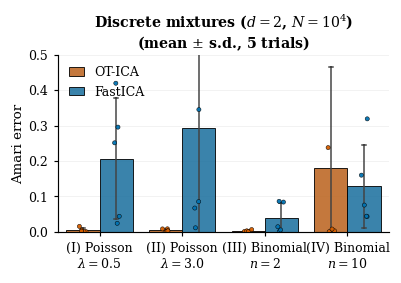

mean     std  count
Method  Config                                            
FastICA (I) Poisson\n$\lambda=0.5$   0.2070  0.1699      5
        (II) Poisson\n$\lambda=3.0$  0.2948  0.3961      5
        (III) Binomial\n$n=2$        0.0382  0.0431      5
        (IV) Binomial\n$n=10$        0.1284  0.1168      5
OT-ICA  (I) Poisson\n$\lambda=0.5$   0.0047  0.0062      5
        (II) Poisson\n$\lambda=3.0$  0.0043  0.0037      5
        (III) Binomial\n$n=2$        0.0023  0.0024      5
        (IV) Binomial\n$n=10$        0.1813  0.2850      5

In [16]:
# =====================================================================
#  F. AMARI BENCHMARK AT d=2  (generates df_harsh, then plots)
# =====================================================================
import re, seaborn as sns

DIST      = [("Poisson", 0.5), ("Poisson", 3.0), ("Binomial", 2), ("Binomial", 10)]
ROMAN     = ["I", "II", "III", "IV"]
N_SAMPLES, N_TRIALS, METHODS = 10_000, 5, ["FastICA", "OT-ICA"]

tasks = [(2, t, N_SAMPLES, d, m, p)
         for (d, p) in DIST for m in METHODS for t in range(N_TRIALS)]
df_harsh = pd.DataFrame(Parallel(n_jobs=8)(
    delayed(run_ica_trial)(*t) for t in tqdm(tasks)))

lbl = {}
for i, (d, p) in enumerate(DIST):
    lbl[(d, p)] = (f"({ROMAN[i]}) {d}\n" +
                   (f"$\\lambda={p}$" if d == "Poisson" else f"$n={int(p)}$"))
df_harsh["Config"] = [lbl[(r.Config, r.Config_Param)] for r in df_harsh.itertuples()]

def safe_name(s):
    s = re.sub(r"\$[^$]*\$", "", s)
    return re.sub(r"_+", "_", re.sub(r"[^0-9a-zA-Z]+", "_", s)).strip("_").lower()

def plot_results(df, title, palette, x_col="Config", ylim=0.5,
                 fname=None, figsize=(3.4, 2.4)):
    d = df.copy(); d["Error"] = d["Error"].fillna(1.5)
    n_tr = int(d.groupby(["Method", x_col]).size().min())
    order = sorted(d[x_col].unique())

    with paper_style():
        fig, ax = plt.subplots(figsize=figsize)
        sns.barplot(data=d, x=x_col, y="Error", hue="Method", ax=ax, order=order,
                    hue_order=["OT-ICA", "FastICA"], palette=palette,
                    edgecolor="black", linewidth=0.6, errorbar="sd",
                    capsize=0.10, err_kws=dict(linewidth=0.9), alpha=0.85)
        sns.stripplot(data=d, x=x_col, y="Error", hue="Method", ax=ax, order=order,
                      hue_order=["OT-ICA", "FastICA"], palette=palette, dodge=True,
                      size=2.5, edgecolor="black", linewidth=0.3,
                      legend=False, alpha=0.95)
        ax.set_ylim(0, ylim); ax.set_xlabel("")
        ax.set_ylabel("Amari error", labelpad=2)
        ax.set_title(f"{title}\n(mean $\\pm$ s.d., {n_tr} trials)",
                     fontweight="bold", pad=4)
        h, l = ax.get_legend_handles_labels()
        ax.legend(h[:2], l[:2], loc="upper left", handlelength=1.2)
        ax.grid(axis="x", visible=False)
        fig.tight_layout()
        fig.savefig(fname or f"{safe_name(title)}.pdf")
        plt.show()

    display(df.groupby(["Method", x_col])["Error"]
              .agg(["mean", "std", "count"]).round(4))

plot_results(df_harsh, "Discrete mixtures ($d=2$, $N=10^4$)",
             palette=PALETTE, fname="discrete_amari_d2.pdf")

In [ ]:
# =====================================================================
#  F2. SIGN TEST: OT-ICA vs FastICA on df_harsh (Table 4 supp / Fig. 4)
#      Pairing unit: trial index t (tasks preserves nested-loop order and
#      joblib.Parallel preserves input order, so df_harsh's rows line up
#      with `tasks` positionally -- recovers the shared-mixture-instance
#      pairing without re-running anything).
# =====================================================================
from scipy.stats import binomtest

df_harsh["Trial"] = [task[1] for task in tasks]

sign_rows = []
for cfg in df_harsh["Config"].unique():
    sub = df_harsh[df_harsh.Config == cfg]
    piv = sub.pivot(index="Trial", columns="Method", values="Error")
    a, b = piv["OT-ICA"], piv["FastICA"]
    mask = a.notna() & b.notna() & (a != b)
    n = int(mask.sum())
    wins = int((a[mask] < b[mask]).sum())
    p = binomtest(wins, n, 0.5, alternative="two-sided").pvalue if n > 0 else np.nan
    sign_rows.append({"Config": cfg, "n_pairs": n, "wins_OT-ICA": wins,
                      "losses_OT-ICA": n - wins, "p_value": p})

sign_harsh = pd.DataFrame(sign_rows)
print("Sign test, OT-ICA vs FastICA, per discrete configuration (n_trials = "
      f"{N_TRIALS}):")
print(sign_harsh.to_string(index=False))
print(f"\nCaveat: with only {N_TRIALS} paired trials, a clean {N_TRIALS}-0 sweep "
      f"gives a two-sided sign-test p-value of "
      f"{binomtest(N_TRIALS, N_TRIALS, 0.5, alternative='two-sided').pvalue:.4f} "
      "-- underpowered to claim significance at alpha=0.05 from this cell alone. "
      "Report the win count/CI alongside (or increase N_TRIALS) rather than only "
      "the p-value.")